In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/taweilo/loan-approval-classification-data/loan_data.csv
/kaggle/input/datasets/mirichoi0218/insurance/insurance.csv


In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("taweilo/loan-approval-classification-data")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/taweilo/loan-approval-classification-data


In [3]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/taweilo/loan-approval-classification-data/loan_data.csv")
df

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
44995,27.0,male,Associate,47971.0,6,RENT,15000.0,MEDICAL,15.66,0.31,3.0,645,No,1
44996,37.0,female,Associate,65800.0,17,RENT,9000.0,HOMEIMPROVEMENT,14.07,0.14,11.0,621,No,1
44997,33.0,male,Associate,56942.0,7,RENT,2771.0,DEBTCONSOLIDATION,10.02,0.05,10.0,668,No,1
44998,29.0,male,Bachelor,33164.0,4,RENT,12000.0,EDUCATION,13.23,0.36,6.0,604,No,1


In [4]:
#df=df.iloc[:,['person_income','loan_amnt','previous_loan_defaults_on_file','loan_status']]
df= df.drop(columns=['person_age','person_gender','person_education','person_emp_exp','person_home_ownership','loan_intent','loan_int_rate','cb_person_cred_hist_length','credit_score'])

In [5]:
import pandas as pd
import numpy as np

import scipy.stats as stats

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression 
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [6]:
df.isnull().sum()

person_income                     0
loan_amnt                         0
loan_percent_income               0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

In [7]:
X= df.iloc[:, :-1]
y= df.iloc[:, -1]

In [8]:
X_train, X_test, y_train, y_test= train_test_split(X,y, test_size = 0.2, random_state=42)

In [9]:
X_train.sample(4)

,person_income,loan_amnt,loan_percent_income,previous_loan_defaults_on_file
44024,51407.0,3023.0,0.06,No
14267,124760.0,24000.0,0.19,No
13523,97966.0,16000.0,0.16,No
14423,96803.0,15000.0,0.15,No


# To View Skewness of Features

/tmp/ipykernel_16/481118193.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['person_income'])


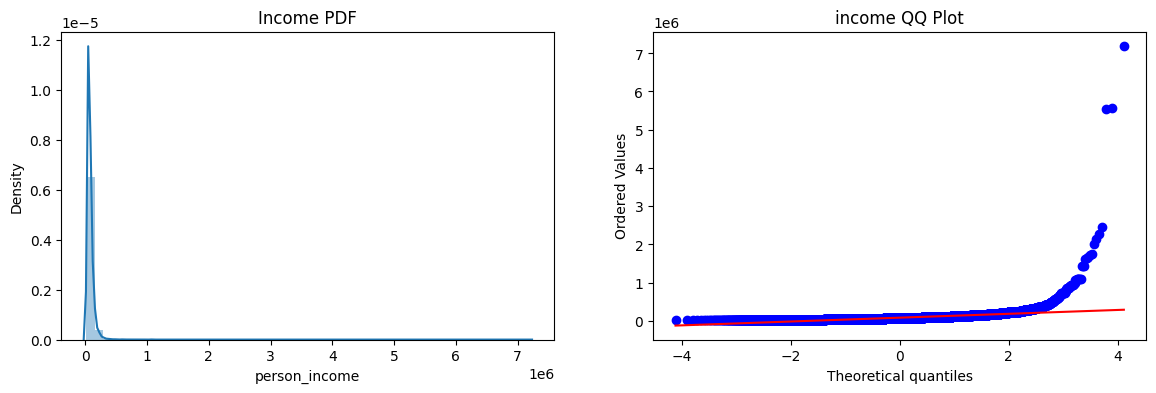

In [10]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['person_income'])
plt.title("Income PDF")

plt.subplot(122)
stats.probplot(X_train['person_income'],dist='norm', plot=plt)
plt.title("income QQ Plot")
plt.show()


In [11]:
X_train['person_income'].skew()

np.float64(35.09150413457532)

/tmp/ipykernel_16/1519480252.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['loan_amnt'])


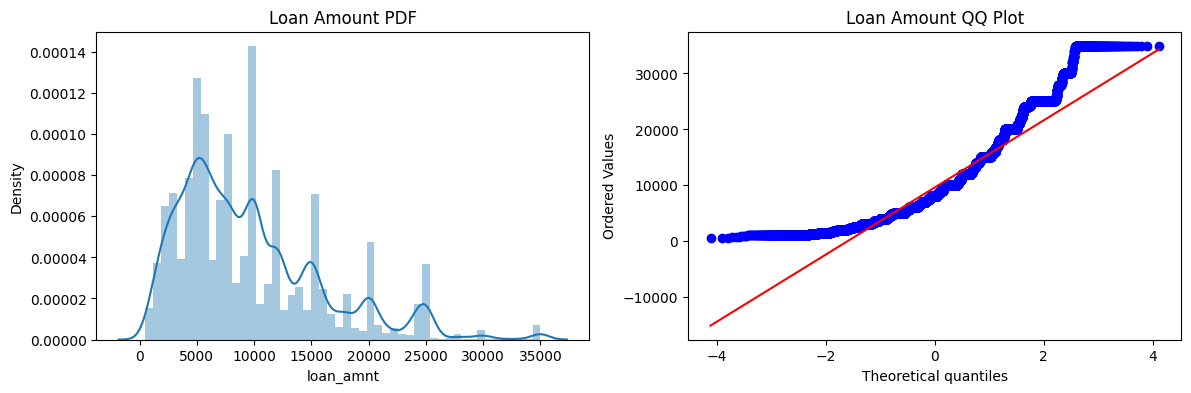

In [12]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['loan_amnt'])
plt.title("Loan Amount PDF")

plt.subplot(122)
stats.probplot(X_train['loan_amnt'],dist='norm', plot=plt)
plt.title("Loan Amount QQ Plot")
plt.show()

In [13]:
X_train['loan_amnt'].skew()

np.float64(1.1740944055795806)

/tmp/ipykernel_16/3682397338.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['loan_percent_income'])


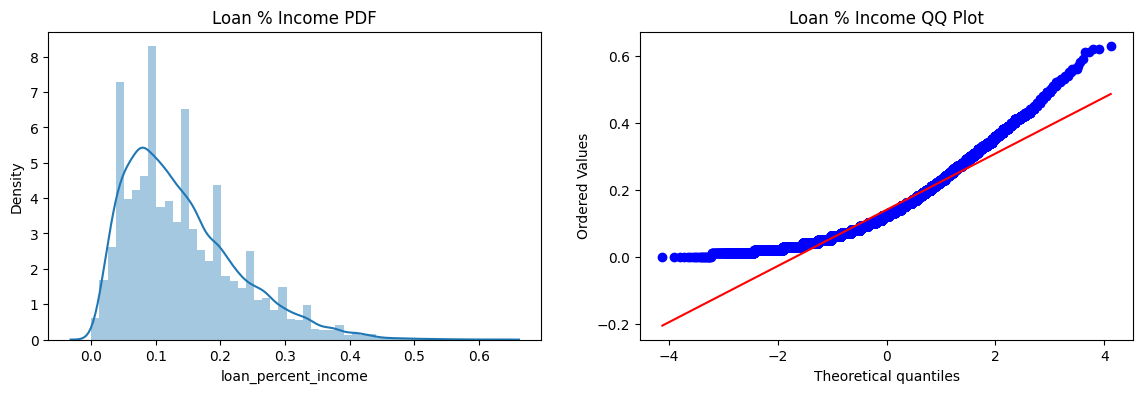

In [14]:
plt.figure(figsize=(14,4))
plt.subplot(121)
sns.distplot(X_train['loan_percent_income'])
plt.title("Loan % Income PDF")

plt.subplot(122)
stats.probplot(X_train['loan_percent_income'],dist='norm', plot=plt)
plt.title("Loan % Income QQ Plot")
plt.show()

In [15]:
X_train['loan_percent_income'].skew()

np.float64(1.0226315129573393)

# Pipeline

In [16]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import make_pipeline, Pipeline

In [17]:
from sklearn.preprocessing import OrdinalEncoder
oe = OrdinalEncoder(categories=[['No','Yes']], handle_unknown='error') #ordinalencoder object
oe.set_output(transform="pandas")

scaler = MinMaxScaler() #min max scaler object
reg = LogisticRegression ()
tree= DecisionTreeClassifier()

# Without Transformers

In [18]:
trf1 = ColumnTransformer([('oe', oe, [-1] )],
                        remainder='passthrough')
trf2 = ColumnTransformer([('scaler',scaler,slice(0,3))],
                        remainder='passthrough')
trf3 = reg

In [19]:
pipeline =Pipeline([
    ('trf1',trf1),
    ('trf2',trf2),
    ('trf3',trf3)
])
pipeline

Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('oe',
                                                  OrdinalEncoder(categories=[['No',
                                                                              'Yes']]),
                                                  [-1])])),
                ('trf2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', MinMaxScaler(),
                                                  slice(0, 3, None))])),
                ('trf3', LogisticRegression())])

In [20]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('oe',
                                                  OrdinalEncoder(categories=[['No',
                                                                              'Yes']]),
                                                  [-1])])),
                ('trf2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', MinMaxScaler(),
                                                  slice(0, 3, None))])),
                ('trf3', LogisticRegression())])

In [21]:
predicted_Y = pipeline.predict(X_test)

In [22]:
accuracy_score (y_test ,predicted_Y)

0.8486666666666667

In [23]:
#now with decision tree but without tranformer
trf3 = DecisionTreeClassifier()

In [24]:
pipeline = Pipeline([('trf1',trf1),
                     ('trf2',trf2),
                     ('trf3',trf3)
                    ])
pipeline

Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('oe',
                                                  OrdinalEncoder(categories=[['No',
                                                                              'Yes']]),
                                                  [-1])])),
                ('trf2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', MinMaxScaler(),
                                                  slice(0, 3, None))])),
                ('trf3', DecisionTreeClassifier())])

In [25]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('oe',
                                                  OrdinalEncoder(categories=[['No',
                                                                              'Yes']]),
                                                  [-1])])),
                ('trf2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', MinMaxScaler(),
                                                  slice(0, 3, None))])),
                ('trf3', DecisionTreeClassifier())])

In [26]:
y_predicted = pipeline.predict (X_test)

In [27]:
accuracy_score(y_predicted, y_test)

0.8618888888888889

# With Transformers

In [28]:
trf = FunctionTransformer(func=np.log1p, validate=True)

In [29]:
X_train.isnull().sum()

person_income                     0
loan_amnt                         0
loan_percent_income               0
previous_loan_defaults_on_file    0
dtype: int64

In [30]:
pipeline = Pipeline([('trf1',trf1),
                     ('trf2',trf2),
                     ('trf3', trf),
                     ('trf4',LogisticRegression())
                    ])
pipeline

Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('oe',
                                                  OrdinalEncoder(categories=[['No',
                                                                              'Yes']]),
                                                  [-1])])),
                ('trf2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', MinMaxScaler(),
                                                  slice(0, 3, None))])),
                ('trf3',
                 FunctionTransformer(func=<ufunc 'log1p'>, validate=True)),
                ('trf4', LogisticRegression())])

In [31]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('oe',
                                                  OrdinalEncoder(categories=[['No',
                                                                              'Yes']]),
                                                  [-1])])),
                ('trf2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', MinMaxScaler(),
                                                  slice(0, 3, None))])),
                ('trf3',
                 FunctionTransformer(func=<ufunc 'log1p'>, validate=True)),
                ('trf4', LogisticRegression())])

In [32]:
predicted_y = pipeline.predict(X_test)

In [33]:
accuracy_score(predicted_y, y_test)

0.8521111111111112

In [34]:
pipeline = Pipeline([('trf1',trf1),
                     ('trf2',trf2),
                     ('trf3', trf),
                     ('trf4',DecisionTreeClassifier())
                    ])
pipeline

Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('oe',
                                                  OrdinalEncoder(categories=[['No',
                                                                              'Yes']]),
                                                  [-1])])),
                ('trf2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', MinMaxScaler(),
                                                  slice(0, 3, None))])),
                ('trf3',
                 FunctionTransformer(func=<ufunc 'log1p'>, validate=True)),
                ('trf4', DecisionTreeClassifier())])

In [35]:
pipeline.fit(X_train,y_train)

Pipeline(steps=[('trf1',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('oe',
                                                  OrdinalEncoder(categories=[['No',
                                                                              'Yes']]),
                                                  [-1])])),
                ('trf2',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('scaler', MinMaxScaler(),
                                                  slice(0, 3, None))])),
                ('trf3',
                 FunctionTransformer(func=<ufunc 'log1p'>, validate=True)),
                ('trf4', DecisionTreeClassifier())])

In [36]:
predicted_y = pipeline.predict(X_test)
accuracy_score(predicted_y, y_test)

0.8616666666666667

In [37]:
#to check mean accuracy by cross validation (cross_val_score) of decision tree only before and after transformation

pipeline2 = Pipeline([   ('trf1',trf1), #ordinal encoder to encode cetegorical data of X
                        #('trf2',trf2), # min max scaler to scaler data
                      #('trf3',trf)    #log tranformer to transform data of X
                     ])

In [38]:
transformed_X_train=pipeline2.fit_transform(X_train)
#pipeline2.fit_transform(X_train)

In [39]:
transformed_X_test = pipeline2.transform(X_test)

((array([-4.11625512, -3.90694279, -3.79268647, ...,  3.79268647,
          3.90694279,  4.11625512]),
  array([   8000.,    8000.,    8000., ..., 5545545., 5556399., 7200766.])),
 (np.float64(50366.235340936575),
  np.float64(80649.18824999999),
  np.float64(0.5886732824233853)))

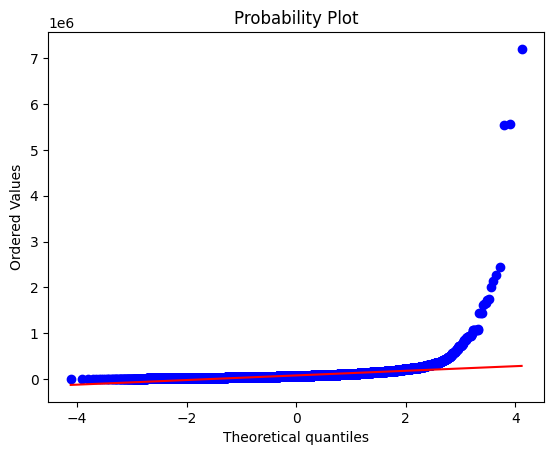

In [40]:
stats.probplot(X_train['person_income'],dist='norm',plot=plt)
